# Training e Fine-tuning di YOLOv8 su Dataset Personalizzato

Questo notebook affronta i due approcci principali per addestrare YOLO su un **dataset custom**.
Entrambi gli esempi usano **lo stesso dataset** per rendere il confronto diretto e significativo.

| Approccio | Quando usarlo | Pro | Contro | Backbone pre-addestrato | Classi YOLO originali mantenute |
|---|---|---|---|---|---|
| **Fine-tuning** | Dataset piccolo (<1000 img), dominio simile a foto naturali | Converge in poche decine di epoche, ottimi risultati anche con pochi dati | Richiede comunque dati annotati di qualita | **Si** — i pesi sono inizializzati da COCO (80 classi di oggetti reali) | **No** — le classi COCO vengono sostituite con le nuove classi, MA rimane la conoscenza visiva del backbone pre-addestrato |
| **Training from scratch** | Dataset grande (>5k img), dominio molto diverso (medico, satellitare...) | Nessun bias da COCO, massima flessibilita | Richiede molti piu dati ed epoche; convergenza piu lenta e instabile | **No** — pesi inizializzati casualmente | **No** — le classi COCO vengono sostituite con le nuove classi |

## 0. Setup

In [4]:
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('/content/Corso-Computer-Vision'):
        !git clone https://github.com/SalvoSamba01/Corso-Computer-Vision
    %cd /content/Corso-Computer-Vision
    !pip install -r requirements.txt -q
else:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', '../requirements.txt'], capture_output=True)

In [5]:
import os
import yaml
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
import cv2

sys.path.append('../utils')
from cv_utils import (disegna_detection,mostra_confronto)

import warnings
warnings.filterwarnings('ignore')

---
## 1. Formato delle annotazioni YOLO e struttura del dataset

Prima di addestrare qualunque modello, e fondamentale capire come YOLO si aspetta i dati.
Il tool di annotazione piu comodo per creare/esportare dataset in questo formato e
[Roboflow](https://roboflow.com) (gratuito), ma anche LabelImg, CVAT e Label Studio supportano
l'esportazione in YOLO format.

### 1.1 Struttura delle cartelle

```
mio_dataset/
|-- data.yaml              <- file di configurazione (obbligatorio)
|-- train/
|   |-- images/            <- immagini di training  (.jpg | .png | .bmp ...)
|   +-- labels/            <- annotazioni           (.txt, una per immagine)
|-- valid/
|   |-- images/
|   +-- labels/
+-- test/                  <- opzionale
    |-- images/
    +-- labels/
```

> Le directory `images/` e `labels/` devono essere allo stesso livello e avere lo stesso nome
> di radice. YOLO trova i `.txt` sostituendo `images` con `labels` nel percorso.

### 1.2 File di annotazione `.txt`

Ogni immagine ha un file `.txt` con lo stesso nome base (es. `foto_001.jpg` -> `foto_001.txt`).
Ogni riga del `.txt` descrive **un oggetto**:

```
<class_id> <cx> <cy> <w> <h>
```

| Campo | Tipo | Significato |
|---|---|---|
| `class_id` | intero | Indice della classe (0-based), coerente con `names` in `data.yaml` |
| `cx`, `cy` | float [0,1] | Centro della bounding box **normalizzato** sulla larghezza/altezza dell'immagine |
| `w`, `h` | float [0,1] | Larghezza e altezza della bounding box **normalizzate** |

**Esempio**: oggetto di classe 2, centrato a 30% da sinistra, 50% dall'alto, largo 20%, alto 15%:
```
2 0.300 0.500 0.200 0.150
```

Se un'immagine non contiene oggetti, il file `.txt` esiste ma e **vuoto**
(o puo essere omesso a seconda del tool — meglio tenerlo vuoto).

### 1.3 File `data.yaml`

```yaml
path: /percorso/assoluto/al/dataset   
train: train/images
val:   valid/images
test:  test/images                     # opzionale

nc: 3                                  # numero di classi (number of classes)
names: ['gatto', 'cane', 'persona']    # nomi nell'ordine degli id (0, 1, 2)
```

### 1.4 Data augmentation automatica

YOLOv8 applica augmentation on-the-fly durante il training (flip, mosaic, mixup, HSV jitter...).
Non è necessario pre-aumentare il dataset manualmente.


In [3]:
# ============================================================
#  SETTING
# ============================================================

if os.path.exists('/content/Corso-Computer-Vision'):
    BASE_DIR = Path('/content/Corso-Computer-Vision')
else:
    BASE_DIR = Path('..').resolve()


DATASET_YAML = '../data/day_3/animals_yolo/data.yaml'   # <- MODIFICARE questo percorso per cambiare dataset

EXPERIMENTS_DIR = BASE_DIR / 'results' / 'full_finetuning'
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR        : {BASE_DIR}')
print(f'EXPERIMENTS_DIR : {EXPERIMENTS_DIR}')

if Path(DATASET_YAML).exists():
    with open(DATASET_YAML) as f:
        data_cfg = yaml.safe_load(f)
    CLASS_NAMES = data_cfg.get('names', [])
    NUM_CLASSES = data_cfg.get('nc', len(CLASS_NAMES))
    print(f'Dataset caricato: {NUM_CLASSES} classi -> {CLASS_NAMES}')
else:
    print(f'[ATTENZIONE] File non trovato: {DATASET_YAML}')
    print('Modifica DATASET_YAML con il percorso corretto al tuo data.yaml.')
    CLASS_NAMES = []
    NUM_CLASSES = 0

BASE_DIR        : /storage/data_1/salvatoresambataro/Corso-Computer-Vision
EXPERIMENTS_DIR : /storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning
Dataset caricato: 5 classi -> ['cat', 'cow', 'dog', 'hen', 'horse']


---
## 2. Fine-tuning di YOLOv8 (Transfer Learning)

Il backbone di YOLOv8 pre-addestrato su COCO ha imparato a riconoscere feature visive
generali: bordi, texture, forme, gradienti. Il fine-tuning sfrutta questa conoscenza
applicandola al tuo problema specifico.

**Come funziona**:
1. I pesi del backbone vengono caricati da COCO
2. L'head di detection viene reinizializzata con `nc` classi del tuo dataset
3. Il training aggiorna tutti i pesi (backbone + head), ma partendo da valori gia buoni

**Risultato**: converge in **20-50 epoche** anche con poche centinaia di immagini.

### Scelta del modello base

| Modello | Parametri | mAP COCO | Velocita (A100 GPU) | Quando usarlo |
|---|---|---|---|---|
| `yolov8n.pt` | 3.2M | 37.3 | ~80 FPS | CPU, mobile, edge, prototipazione rapida |
| `yolov8s.pt` | 11.2M | 44.9 | ~50 FPS | **Bilanciato — buon punto di partenza** |
| `yolov8m.pt` | 25.9M | 50.2 | ~25 FPS | GPU consumer, buona accuratezza |
| `yolov8l.pt` | 43.7M | 52.9 | ~15 FPS | Produzione, GPU dedicata |
| `yolov8x.pt` | 68.2M | 53.9 | ~10 FPS | Massima accuratezza, inferenza non real-time |

In [14]:
# ============================================================
#  FINE-TUNING -- parametri configurabili
# ============================================================

FT_MODEL      = 'yolov8m.pt'          # modello pre-addestrato (scaricato automaticamente)
FT_DATA       = DATASET_YAML          # dataset.yaml
FT_EPOCHS     = 100                    # epoche di finetuning
FT_BATCH      = 64                    # processamento parallelo di immagini
#FT_PATIENCE   = 30                    # se mAP non migliora per N epoche, il training si ferma
FT_PROJECT    = str(EXPERIMENTS_DIR)
FT_NAME       = 'finetune_run'
FT_PRETRAINED = True                  # <- TRUE: usa i pesi pre-addestrati su COCO

print('Configurazione fine-tuning:')
print(f'  model     : {FT_MODEL}')
print(f'  data      : {FT_DATA}')
print(f'  epochs    : {FT_EPOCHS}')
print(f'  batch     : {FT_BATCH}')
#print(f'  patience  : {FT_PATIENCE}')
print(f'  pretrained: {FT_PRETRAINED}')


Configurazione fine-tuning:
  model     : yolov8m.pt
  data      : ../data/day_3/animals_yolo/data.yaml
  epochs    : 100
  batch     : 64
  pretrained: True


In [15]:
model_ft = YOLO(FT_MODEL)

print('--- Inizio fine-tuning ---')
print(f'Epoche: {FT_EPOCHS}  |  Dataset: {FT_DATA}')

results_ft = model_ft.train(
    data       = FT_DATA,
    epochs     = FT_EPOCHS,
    batch      = FT_BATCH,
    #patience   = FT_PATIENCE,
    project    = FT_PROJECT,
    name       = FT_NAME,
    exist_ok   = True,
    pretrained = FT_PRETRAINED,
    device = 0
)

print('--- Fine-tuning completato ---')
print(f'Modello salvato in: {results_ft.save_dir}')

--- Inizio fine-tuning ---
Epoche: 100  |  Dataset: ../data/day_3/animals_yolo/data.yaml
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100 80GB PCIe, 81154MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/day_3/animals_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_

### Cosa stiamo misurando: le metriche di YOLO

Prima di visualizzare i grafici, e importante capire cosa rappresenta ogni metrica.

---

#### Loss (funzioni di costo) — valore da minimizzare

| Metrica | Cosa misura |
|---|---|
| **box_loss** | Errore sulla posizione e dimensione delle bounding box (usa DIoU/CIoU loss) |
| **cls_loss** | Errore sulla classificazione dell'oggetto (cross-entropy) |
| **dfl_loss** | Distribution Focal Loss — errore sulla distribuzione della posizione dei bordi |

In un training sano, tutte le loss **scendono** nel tempo.
Se `val_loss` smette di scendere mentre `train_loss` continua -> **overfitting**.

---

#### Metriche di rilevamento — valore da massimizzare

**Precision (P)**: di tutti gli oggetti che il modello ha rilevato, quanti erano reali?
```
P = TP / (TP + FP)
```
Alta Precision = pochi falsi positivi (il modello non "inventa" oggetti).

**Recall (R)**: di tutti gli oggetti reali presenti, quanti ha trovato il modello?
```
R = TP / (TP + FN)
```
Alto Recall = pochi falsi negativi (il modello non "manca" oggetti).

> Precision e Recall sono in trade-off: abbassando la soglia di confidenza aumenta il recall
> ma diminuisce la precision (e viceversa). Per questo si usa la curva PR.

**mAP@50** (mean Average Precision a IoU=0.5): la metrica principale per la detection.
- Per ogni classe calcola l'area sotto la curva Precision-Recall con soglia IoU=0.50
- Poi fa la media su tutte le classi
- IoU=0.50 significa che una predizione e corretta se si sovrappone almeno al 50% con il ground truth

**mAP@50-95**: versione piu rigorosa — media di mAP calcolata per soglie IoU da 0.50 a 0.95 a step di 0.05.
E la metrica ufficiale del benchmark COCO. Un mAP50-95 > 0.50 e considerato molto buono.

---

#### Interpretazione pratica

| Scenario | Sintomo | Causa probabile |
|---|---|---|
| Loss scende, mAP sale | Tutto normale | Training sano |
| `val/box_loss` sale dopo un po' | Overfitting sulle bbox | Troppo poche immagini o troppi epochs |
| `train/cls_loss` non scende | Underfitting | LR troppo bassa, classi mal bilanciate |
| mAP@50 alto, mAP@50-95 basso | Box imprecise | Il modello trova gli oggetti ma le bbox sono approssimative |
| Recall basso, Precision alta | Modello troppo conservativo | Confidence threshold troppo alto |


### Metriche di training

Vengono salvate automaticamente nella cartella del run:
- `results.csv` — loss e metriche per ogni epoca
- `confusion_matrix.png`, `PR_curve.png`, `F1_curve.png` — grafici diagnostici
- `weights/best.pt` — checkpoint con il miglior mAP50-95
- `weights/last.pt` — ultimo checkpoint salvato


### Esempio di detection con il nuovo modello


Possibili classi:  {0: 'cat', 1: 'cow', 2: 'dog', 3: 'hen', 4: 'horse'}

image 1/1 /storage/data_1/salvatoresambataro/Corso-Computer-Vision/data/day_3/animals_yolo/catsdogs2.jpg: 480x640 2 cats, 4.4ms
Speed: 1.9ms preprocess, 4.4ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


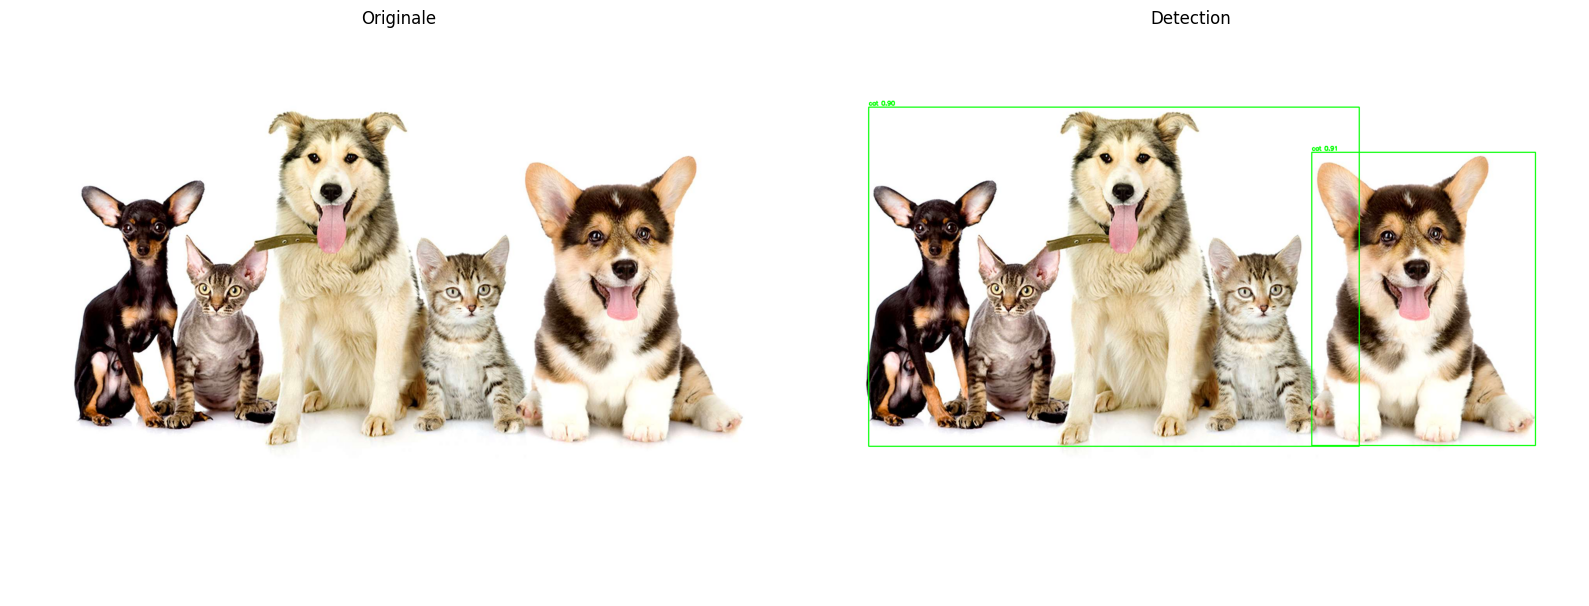

In [29]:
model = YOLO("../results/full_finetuning/finetune_run/weights/best.pt")

print ("Possibili classi: " , model.names)
#img_path = "../data/day_3/animals_yolo/test/images/cow-146-_jpeg.rf.8f691d117307cd576c58ba0084b99832.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/horse-143-_jpeg.rf.8ea31512f0e85e9fbac8abe6cf09575f.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/hen-114-_jpeg.rf.9fb6e63cc38ff91fe8a6647848d3205a.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/dog-136-_jpeg.rf.3e68138ecd2d5b85173f60d93be0cc29.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/cat-138-_jpg.rf.4f21d13debbc7cf3c4a8c9367863f741.jpg"
img_path = "/storage/data_1/salvatoresambataro/Corso-Computer-Vision/data/day_3/animals_yolo/catsdogs2.jpg"

img = cv2.imread(img_path)

res = model(img_path, conf=0.2)

%matplotlib inline

img_det = disegna_detection(img, res, soglia_conf=0.1, nomi_classi=model.names)

mostra_confronto(img, img_det, titolo_sx="Originale", titolo_dx="Detection")

---
## 3. Training From Scratch

Parte da pesi inizializzati **casualmente**: nessuna conoscenza pre-acquisita.
Usato quando il dominio visivo è radicalmente diverso dalle immagini naturali di COCO
(es. microscopia, immagini termiche, radar, raggi X) oppure quando si hanno molti dati.

**Come funziona**:
1. I pesi del backbone vengono inizializzati casualmente (o con tecniche apposite)
2. L'head di detection viene inizializzata casualmente con `nc` classi del tuo dataset
3. Il training deve imparare tutto da zero: feature di basso livello (bordi, texture)
   e di alto livello (forme, oggetti complessi) insieme

**Trade-off**: richiede **più epoche** e **più dati** rispetto al fine-tuning
per raggiungere prestazioni simili. Durante le prime epoche la loss è molto alta e instabile.

**Stesso dataset del fine-tuning**: confrontare i due approcci sullo stesso dataset permette
di vedere chiaramente il vantaggio del transfer learning in termini di velocita di convergenza
e qualita finale, specialmente con dataset piccoli.


In [4]:
# ============================================================
#  TRAINING FROM SCRATCH -- parametri configurabili
# ============================================================

# yolov8n.yaml carica SOLO l'architettura (nessun peso pre-addestrato).
# Equivale a: YOLO('yolov8n.pt') con pretrained=False
SC_MODEL         = 'yolov8m.yaml'
SC_DATA          = DATASET_YAML        # stesso dataset del fine-tuning per confronto diretto
SC_EPOCHS        = 150                 # servono molte piu epoche rispetto al fine-tuning
SC_IMGSZ         = 640
SC_BATCH         = 64
SC_LR0           = 0.01
SC_LRF           = 0.001               # lr finale piu bassa: decadimento piu lento
SC_WARMUP_EPOCHS = 10                  # warmup piu lungo: i pesi sono casuali, serve stabilita
#SC_PATIENCE      = 30                  # early stopping
SC_PROJECT       = str(EXPERIMENTS_DIR)
SC_NAME          = 'full_training_from_scratch_run'
SC_PRETRAINED    = False               # <- FALSE: training from scratch

print('Configurazione training from scratch:')
print(f'  model         : {SC_MODEL}')
print(f'  data          : {SC_DATA}')
print(f'  epochs        : {SC_EPOCHS}')
print(f'  imgsz         : {SC_IMGSZ}')
print(f'  batch         : {SC_BATCH}')
print(f'  lr0           : {SC_LR0}')
print(f'  lrf           : {SC_LRF}')
print(f'  warmup_epochs : {SC_WARMUP_EPOCHS}')
#print(f'  patience      : {SC_PATIENCE}')
print(f'  pretrained    : {SC_PRETRAINED}')


Configurazione training from scratch:
  model         : yolov8m.yaml
  data          : ../data/day_3/animals_yolo/data.yaml
  epochs        : 150
  imgsz         : 640
  batch         : 64
  lr0           : 0.01
  lrf           : 0.001
  warmup_epochs : 10
  pretrained    : False


In [5]:
model_scratch = YOLO(SC_MODEL)

print('--- Inizio training from scratch ---')
print('I pesi sono casuali: le prime epoche la loss sara alta e instabile.')
print('E normale: il modello deve imparare tutto da zero.')

results_scratch = model_scratch.train(
    data          = SC_DATA,
    epochs        = SC_EPOCHS,
    imgsz         = SC_IMGSZ,
    batch         = SC_BATCH,
    lr0           = SC_LR0,
    lrf           = SC_LRF,
    warmup_epochs = SC_WARMUP_EPOCHS,
    #patience      = SC_PATIENCE,
    project       = SC_PROJECT,
    name          = SC_NAME,
    exist_ok      = True,
    pretrained    = SC_PRETRAINED,
    device = 0,
    workers = 0
)

print('--- Training from scratch completato ---')
print(f'Modello salvato in: {results_scratch.save_dir}')


--- Inizio training from scratch ---
I pesi sono casuali: le prime epoche la loss sara alta e instabile.
E normale: il modello deve imparare tutto da zero.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100 80GB PCIe, 81154MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/day_3/animals_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

---
## 4. Confronto: Fine-tuning vs Training From Scratch

Entrambi i training hanno usato lo **stesso dataset** e lo stesso modello base.
Il confronto e diretto: l'unica variabile e il punto di partenza dei pesi.


---
## 5. Inferenza con modello trained from scratch

Possibili classi:  {0: 'cat', 1: 'cow', 2: 'dog', 3: 'hen', 4: 'horse'}

image 1/1 /storage/data_1/salvatoresambataro/Corso-Computer-Vision/notebooks/../data/day_3/animals_yolo/test/images/cow-146-_jpeg.rf.8f691d117307cd576c58ba0084b99832.jpg: 448x640 4 cows, 1 horse, 4.2ms
Speed: 1.2ms preprocess, 4.2ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


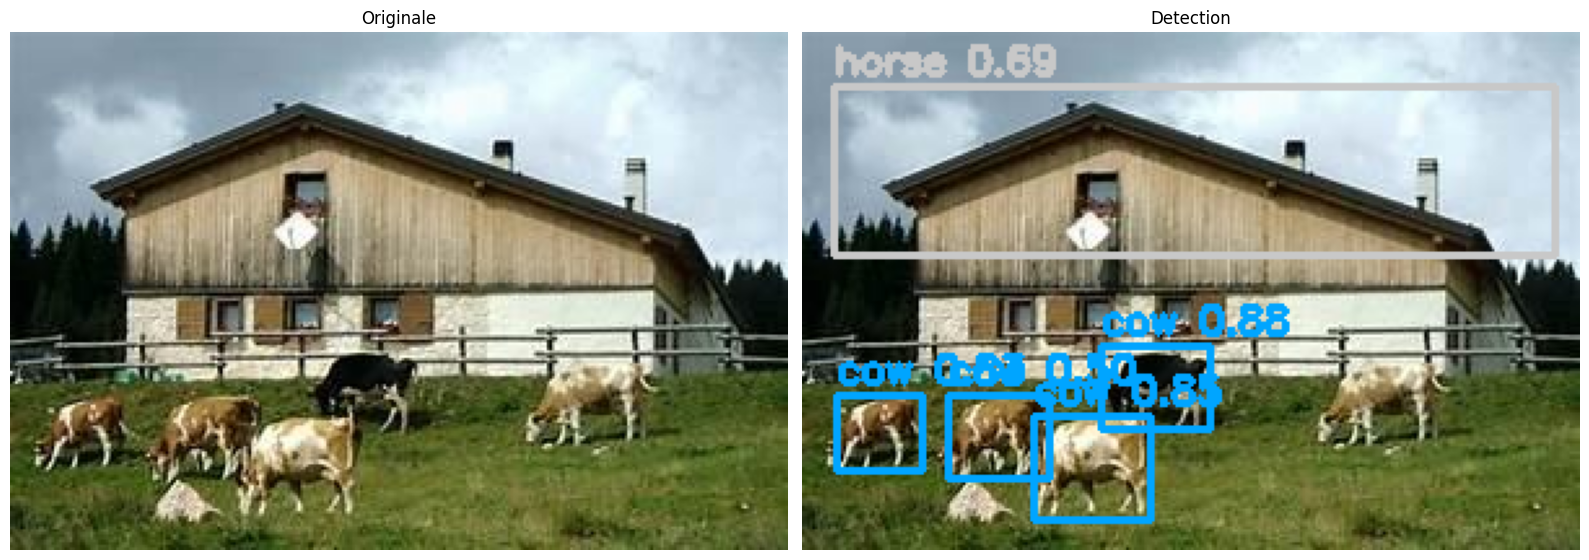

In [18]:
model = YOLO("../results/full_finetuning/full_training_from_scratch_run/weights/best.pt")

print ("Possibili classi: " , model.names)
img_path = "../data/day_3/animals_yolo/test/images/cow-146-_jpeg.rf.8f691d117307cd576c58ba0084b99832.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/horse-143-_jpeg.rf.8ea31512f0e85e9fbac8abe6cf09575f.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/hen-114-_jpeg.rf.9fb6e63cc38ff91fe8a6647848d3205a.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/dog-136-_jpeg.rf.3e68138ecd2d5b85173f60d93be0cc29.jpg"
#img_path = "../data/day_3/animals_yolo/test/images/cat-138-_jpg.rf.4f21d13debbc7cf3c4a8c9367863f741.jpg"
#img_path = "/storage/data_1/salvatoresambataro/Corso-Computer-Vision/data/day_3/animals_yolo/catsdogs2.jpg"

img = cv2.imread(img_path)

res = model(img_path)

%matplotlib inline

img_det = disegna_detection(img, res, soglia_conf=0.1, nomi_classi=model.names)

mostra_confronto(img, img_det, titolo_sx="Originale", titolo_dx="Detection")

---
## 6. Esportazione del modello

Una volta addestrato e validato, esporti il modello nel formato ottimale per il deployment.


In [ ]:
best_weights = Path("/storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.pt")

if best_weights.exists():
    model_export = YOLO(str(best_weights))
    # ONNX è il formato piu universale per il deployment cross-platform
    onnx_path    = model_export.export(format='onnx', imgsz=640, simplify=True)
    print(f'Modello esportato: {onnx_path}')

else:
    print('Esegui prima il fine-tuning.')


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.6.0+cu124 CPU (Intel Xeon Gold 5416S)
YOLOv8m summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (49.6 MB)

ONNX: starting export with onnx 1.21.0 opset 19...


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 2.0s, saved as '/storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.onnx' (98.8 MB)

Export complete (2.4s)
Results saved to /storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights
Predict:         yolo predict task=detect model=/storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.onnx imgsz=640 data=../data/day_3/animals_yolo/data.yaml  
Visualize:       https://netron.app
Modello esportato: /storage/data_1/salvatoresambataro/Corso-Computer-Vision/results/full_finetuning/full_training_from_scratch_run/weights/best.onnx

Altri formati dis

### Altri formati disponibili:
- **TFLite**: Android, microcontrollori, edge devices
- **CoreML**: iOS e macOS (Apple Silicon)
- **TensorRT**: formato ottimizzato per NVIDIA GPU

---
## Riepilogo e Regole Pratiche

### Cheatsheet: le 3 righe fondamentali

**Fine-tuning (transfer learning)**
```python
from ultralytics import YOLO
model = YOLO('yolov8n.pt')                        # backbone COCO pre-addestrato
model.train(data='data.yaml', epochs=50)           # adatta al tuo dataset
```

**Training from scratch**
```python
from ultralytics import YOLO
model = YOLO('yolov8n.yaml')                       # solo architettura, pesi casuali
model.train(data='data.yaml', epochs=150, pretrained=False, warmup_epochs=10)
```

**Valutazione e inferenza**
```python
model   = YOLO('runs/detect/train/weights/best.pt')
metrics = model.val(data='data.yaml')              # mAP, precision, recall
results = model.predict('img.jpg', conf=0.25)      # inferenza su immagine/video/cartella
model.export(format='onnx')                        # esporta per deployment
```

---

### Quale approccio scegliere?

| Situazione | Approccio consigliato | Motivazione |
|---|---|---|
| Dataset < 200 img | Fine-tuning con augmentation aggressiva | Il backbone pre-addestrato compensa la mancanza di dati |
| Dataset 200-2000 img | Fine-tuning | Il punto di partenza dei pesi vale piu dei dati aggiuntivi |
| Dataset > 5000 img, dominio simile a COCO | Fine-tuning | Ancora conveniente, converge prima |
| Dataset > 5000 img, dominio molto diverso | Training from scratch | Il backbone COCO potrebbe introdurre bias non utili |
| Vincoli legali sui pesi | Training from scratch | Impossibile usare pesi COCO se non autorizzati |
| Prototipazione rapida | Fine-tuning con `yolov8n` | Risultati decenti in pochi minuti |

---

### A cosa fare attenzione?

- Iperparametri chiave e come regolarli
- Andamento del training (over/under-fitting)
- Qualita dei dati: Bilanciamento delle classi, Qualita delle annotazioni, Varieta delle immagini